# <center>**LastFM Data Science Project**</center>

## **Import Libraries**

In [3]:
import pylast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor, as_completed
from bs4 import BeautifulSoup
import requests
from sklearn.preprocessing import MultiLabelBinarizer

# **Data Preparation**

## **Get API Access**

In [6]:
API_KEY = "2d901b318bd2a5c736ca66d22eadf0ae"
API_SECRET = "daa7b060a8bee7f17c7ba9f88d2f535f"
network = pylast.LastFMNetwork(
    api_key=API_KEY,
    api_secret=API_SECRET
)

# test connection
user = network.get_user('cosmeticstm')
print(user.get_name())

cosmeticstm


## **Get dynamic threshold for limit parameter**

In [8]:
def get_dynamic_threshold(user, fetch_limit=1000, percentile=75):
    '''
    Set threshold at the nth percentile of play counts
    '''
    import numpy as np
    
    top_artists = user.get_top_artists(limit=fetch_limit)
    play_counts = [int(a.weight) for a in top_artists]
    
    threshold = int(np.percentile(play_counts, percentile))
    print(f"Dynamic threshold ({percentile}th percentile): {threshold} plays")
    
    meaningful = [a for a in top_artists if int(a.weight) >= threshold]
    print(f"Artists above threshold: {len(meaningful)}")
    
    return meaningful

play_count = get_dynamic_threshold(user)

Dynamic threshold (75th percentile): 88 plays
Artists above threshold: 255


=== Distribution Summary ===
Total artists: 1000
Max plays: 7069
Min plays: 3
Median plays: 25
Mean plays: 148.55
Std dev: 501.07


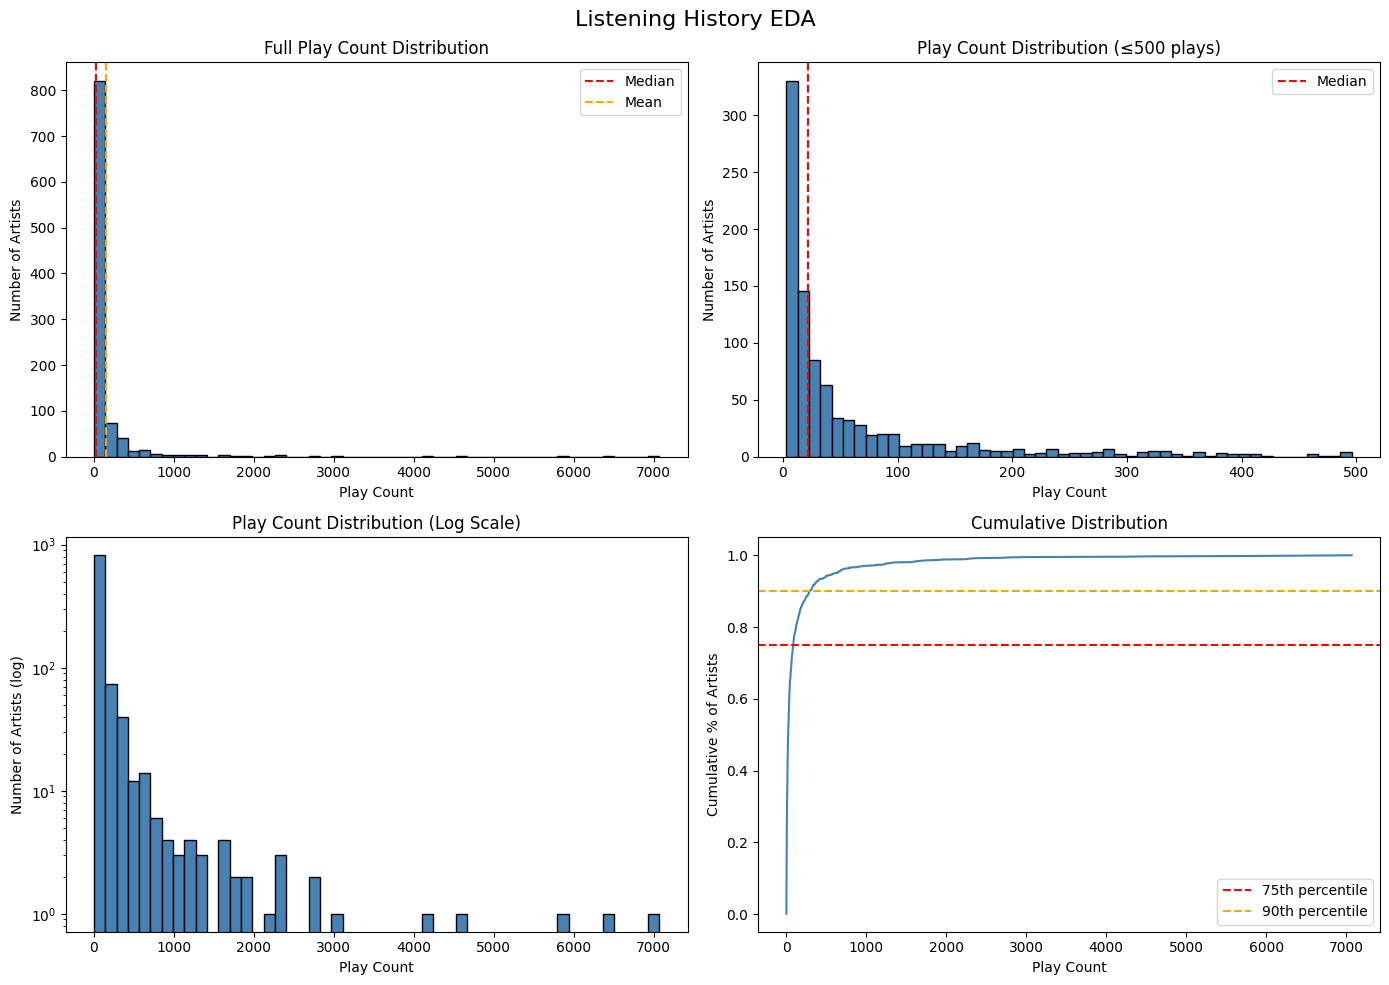

In [9]:
# EDA top artists edition
exploratory_artists = user.get_top_artists(limit=1000)
play_counts = [int(a.weight) for a in exploratory_artists]

# Basic stats
print("=== Distribution Summary ===")
print(f"Total artists: {len(play_counts)}")
print(f"Max plays: {max(play_counts)}")
print(f"Min plays: {min(play_counts)}")
print(f"Median plays: {int(np.median(play_counts))}")
print(f"Mean plays: {np.mean(play_counts):.2f}")
print(f"Std dev: {np.std(play_counts):.2f}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Listening History EDA', fontsize=16)

# 1. Full distribution
axes[0,0].hist(play_counts, bins=50, color='steelblue', edgecolor='black')
axes[0,0].set_title('Full Play Count Distribution')
axes[0,0].set_xlabel('Play Count')
axes[0,0].set_ylabel('Number of Artists')
axes[0,0].axvline(np.median(play_counts), color='red', linestyle='--', label='Median')
axes[0,0].axvline(np.mean(play_counts), color='orange', linestyle='--', label='Mean')
axes[0,0].legend()

# 2. Zoomed in
zoomed = [p for p in play_counts if p <= 500]
axes[0,1].hist(zoomed, bins=50, color='steelblue', edgecolor='black')
axes[0,1].set_title('Play Count Distribution (≤500 plays)')
axes[0,1].set_xlabel('Play Count')
axes[0,1].set_ylabel('Number of Artists')
axes[0,1].axvline(np.median(zoomed), color='red', linestyle='--', label='Median')
axes[0,1].legend()

# 3. Log scale distribution
axes[1,0].hist(play_counts, bins=50, color='steelblue', edgecolor='black', log=True)
axes[1,0].set_title('Play Count Distribution (Log Scale)')
axes[1,0].set_xlabel('Play Count')
axes[1,0].set_ylabel('Number of Artists (log)')

# 4. Cumulative distribution
sorted_counts = np.sort(play_counts)
cumulative = np.arange(1, len(sorted_counts)+1) / len(sorted_counts)
axes[1,1].plot(sorted_counts, cumulative, color='steelblue')
axes[1,1].set_title('Cumulative Distribution')
axes[1,1].set_xlabel('Play Count')
axes[1,1].set_ylabel('Cumulative % of Artists')
axes[1,1].axhline(0.75, color='red', linestyle='--', label='75th percentile')
axes[1,1].axhline(0.90, color='orange', linestyle='--', label='90th percentile')
axes[1,1].legend()

plt.tight_layout()
plt.show()

**Insights:**
- Based on the EDA, both median and mean play counts are relatively distributed <1000 plays, meaning more 

## **Get top artists**

In [12]:
def fetch_artist_data(artist):
    '''Fetch data for a single artist, including tags.'''
    try:
        tags = artist.item.get_top_tags(limit=15) # set to any limit
        tag_names = [tag.item.name.lower() for tag in tags]
    except pylast.WSError as e:
        print(f"Could not fetch tags for '{artist.item.name}': {e}")
        tag_names = []

    return {
        'artist_name': artist.item.name,
        'play_count': int(artist.weight),
        'url': artist.item.get_url(),
        'tags': tag_names
    }

def parse_top_artists(top_artists, max_workers=10):
    '''
    Convert top artists to DataFrame format, including top tags.
    Fetches tags concurrently to reduce runtime.
    '''
    results = [None] * len(top_artists)  # preserve order

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        future_to_index = {
            executor.submit(fetch_artist_data, artist): i
            for i, artist in enumerate(top_artists)
        }
        for future in as_completed(future_to_index):
            i = future_to_index[future]
            results[i] = future.result()

    return pd.DataFrame(results)

# Usage
top_artists = user.get_top_artists(limit=len(play_count))
artists_df = parse_top_artists(top_artists, max_workers=10)
print(artists_df.head())
print(f'Dataframe Shape: {artists_df.shape}')

     artist_name  play_count                                         url  \
0     Kanye West        7069      https://www.last.fm/music/kanye%2bwest   
1   Lil Uzi Vert        6400  https://www.last.fm/music/lil%2buzi%2bvert   
2  Playboi Carti        5850   https://www.last.fm/music/playboi%2bcarti   
3         Bladee        4576            https://www.last.fm/music/bladee   
4          Lucki        4206             https://www.last.fm/music/lucki   

                                                tags  
0  [hip-hop, rap, hip hop, rnb, kanye west, gay f...  
1  [trap, hip-hop, rap, emo rap, pop rap, hip hop...  
2  [trap, cloud rap, hip-hop, rap, rage, hip hop,...  
3  [cloud rap, trap, drain, hip-hop, hip hop, emo...  
4  [pop, dance, lucki, swedish, trap, female voca...  
Dataframe Shape: (255, 4)


# **Data Preprocessing**

## **Scrape list of valid tags / genres from MusicBrainz.org**

In [15]:
url = 'https://musicbrainz.org/genres' # URL to be scraped
page = requests.get(url) # use requests library

soup = BeautifulSoup(page.text, 'html') # use BS to read html

In [16]:
# remove comments from genres
for comment in soup.find_all('span', class_='comment'):
    comment.decompose()

genres = soup.find_all('bdi') # find all <bdi> tags 

valid_genres = set(genre.text.lower().strip() for genre in genres)

## **Filter valid genres with tags df** 

In [18]:
artists_df['tags'] = artists_df['tags'].apply(
    lambda tags: [tag for tag in tags if tag in valid_genres]
)
print(artists_df.head())

     artist_name  play_count                                         url  \
0     Kanye West        7069      https://www.last.fm/music/kanye%2bwest   
1   Lil Uzi Vert        6400  https://www.last.fm/music/lil%2buzi%2bvert   
2  Playboi Carti        5850   https://www.last.fm/music/playboi%2bcarti   
3         Bladee        4576            https://www.last.fm/music/bladee   
4          Lucki        4206             https://www.last.fm/music/lucki   

                                            tags  
0                     [hip hop, pop, electronic]  
1   [trap, emo rap, pop rap, hip hop, cloud rap]  
2        [trap, cloud rap, rage, hip hop, plugg]  
3  [cloud rap, trap, hip hop, emo rap, hyperpop]  
4          [pop, dance, trap, techno, cloud rap]  


## **Check for null tags**

In [20]:
null_tags = artists_df[artists_df['tags'].str.len() == 0]
num_null_tags = len(null_tags)

print(null_tags)
print(f'\nNumber of null tags / genres: {num_null_tags}')

                     artist_name  play_count  \
82                alex_g_offline         347   
111               jaydes archive         273   
151                       yenny*         177   
165                 alexgoffline         161   
195               Ligaya Escueta         127   
220                     Kimaurii         105   
252  Lil Uzi Vert, Playboi Carti          88   

                                                   url tags  
82            https://www.last.fm/music/alex_g_offline   []  
111         https://www.last.fm/music/jaydes%2barchive   []  
151               https://www.last.fm/music/yenny%252a   []  
165             https://www.last.fm/music/alexgoffline   []  
195         https://www.last.fm/music/ligaya%2bescueta   []  
220                 https://www.last.fm/music/kimaurii   []  
252  https://www.last.fm/music/lil%2buzi%2bvert%252...   []  

Number of null tags / genres: 7


**Insights:**

I decided to drop the 7 artists with null tags since `alex_g_offline`, `alexgoffline`, `jaydes archive`, and `yenny*` are unofficial archival accounts, not real artists, while `Ligaya Escueta` and `Kimaurii` are niche artists that didn't have any tag data, and thus won't contribute anything meaningfully to ML. `Lil Uzi Vert, Playboi Carti` are artifacts that came from Spotify Local Files scrobbling.

### **Prune null tags**

In [23]:
artists_df = artists_df[artists_df['tags'].apply(len) > 0].reset_index(drop=True)

null_tags = artists_df[artists_df['tags'].str.len() == 0]
num_null_tags = len(null_tags)

print(f'Number of null tags / genres: {num_null_tags}')
print(f'Dataframe Shape: {artists_df.shape}')

Number of null tags / genres: 0
Dataframe Shape: (248, 4)


## **Check for sparse tags**

In [25]:
all_tags = [tag for tags in artists_df['tags'] for tag in tags] # Loops to find each tag in tags column

tag_series = pd.Series(all_tags) # Converts into series
tag_counts = tag_series.value_counts() # Counts how many times tag appears

sparse_tags = set(tag_counts[tag_counts < 5].index)
print(sparse_tags)

{'j-pop', 'east coast hip hop', 'underground hip hop', 'dance', 'french house', 'jazz rap', 'post-punk revival', 'noise', 'symphonic black metal', 'depressive black metal', 'uk garage', 'soft rock', 'industrial', 'tarantella', 'drum and bass', 'contemporary folk', 'tread', 'euro-trance', 'bossa nova', 'opm', 'grindcore', 'techno', 'gothic rock', 'progressive metalcore', 'house', 'drill', 'vaporwave', 'jangle pop', 'ethereal wave', 'heavy metal', 'sound collage', 'space rock', 'reggae', 'jump up', 'math pop', 'avant-garde jazz', 'crust punk', 'boom bap', 'experimental rock', 'technical death metal', 'instrumental', 'geek rock', 'garage rock', 'ghetto house', 'trap metal', 'j-rock', 'future bass', 'gospel', 'funk metal', 'classic rock', 'ambient pop', 'r&b', 'power pop', 'uk hardcore', 'dubstep', 'rap metal', 'minimal synth', 'regalia', 'rapcore', 'memphis rap', 'k-pop', 'witch house', 'death metal', 'black metal', 'downtempo', 'dance-pop', 'skate punk', 'garage rock revival', 'ambient a

### **Remove sparse tags and check null tags**

In [27]:
artists_df['tags'] = artists_df['tags'].apply(
    lambda tags: [tag for tag in tags if tag not in sparse_tags]
) # Checks if tag is not in sparse_tags

print(artists_df[artists_df['tags'].apply(len) == 0]) # Checks artists with null tags

null_tags = artists_df[artists_df['tags'].str.len() == 0]
num_null_tags = len(null_tags)

print(f'Number of null tags / genres: {num_null_tags}')

    artist_name  play_count                             url tags
210        Yuke         110  https://www.last.fm/music/yuke   []
Number of null tags / genres: 1


### **Remove null tags**

In [29]:
artists_df = artists_df[artists_df['tags'].apply(len) > 0].reset_index(drop=True)

null_tags = artists_df[artists_df['tags'].str.len() == 0]
num_null_tags = len(null_tags)

print(f'Number of null tags / genres: {len(null_tags)}')
print(f'Dataframe Shape: {artists_df.shape}')

Number of null tags / genres: 0
Dataframe Shape: (247, 4)


## **Feature Engineering**

In [31]:
mlb = MultiLabelBinarizer()
ohe = pd.DataFrame(
    mlb.fit_transform(artists_df['tags']),
    columns=mlb.classes_,
    index=artists_df.index
)

final_df = pd.concat([artists_df, ohe], axis=1)
print(f'Final Dataframe Shape: {final_df.shape}')

Final Dataframe Shape: (247, 58)


# **Exploratory Data Analysis (EDA)**